# Exploración de `movies` + `ratings` — Dataset MovieLens

**Parte:** Ítem (`movies`) + Data (`ratings`)
**Responsable:** Ricardo Andrés Ayala Garzón
**Notebook:** `movies_ratings.ipynb`

## Introducción

Este notebook cubre la exploración conjunta de las tablas `movies` (catálogo de películas) y `ratings`
(calificaciones numéricas otorgadas por los usuarios). El objetivo es caracterizar el catálogo de
películas, la distribución de las calificaciones, y las relaciones que emergen al combinar ambas
tablas (popularidad, calidad percibida, géneros y evolución temporal).

No se utiliza información de la tabla `tags` en este notebook (esa combinación se trabaja en
`movies_tags_ratings.ipynb`).

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

pd.set_option("display.max_colwidth", 80)


## 2. Carga de datos

Los CSV procesados (`movies.csv`, `ratings.csv`) se encuentran en `data/processed/` en la raíz del
repositorio. Como este notebook vive en `notebooks/exploration/group_20_movies/main/`, se resuelve
la ruta buscando la carpeta `data/processed` hacia arriba en el árbol de directorios en vez de
asumir una profundidad fija (evita romper el notebook si alguien lo mueve de carpeta).

In [2]:
def find_data_dir(start: Path, target=("data", "processed")) -> Path:
    """Busca hacia arriba desde `start` la carpeta data/processed."""
    current = start.resolve()
    for _ in range(6):
        candidate = current.joinpath(*target)
        if candidate.exists():
            return candidate
        current = current.parent
    raise FileNotFoundError(
        f"No se encontró data/processed subiendo desde {start}. "
        "Ajusta DATA_DIR manualmente si la estructura del repo es distinta."
    )

DATA_DIR = find_data_dir(Path.cwd())
print("Usando DATA_DIR:", DATA_DIR)

movies = pd.read_csv(DATA_DIR / "movies.csv")

# ratings.csv tiene ~32M filas (~1.2 GB): se cargan solo las columnas necesarias para el
# análisis numérico (userId, movieId, rating) con dtypes reducidos para no agotar memoria.
# `rating_datetime` se deja fuera de este DataFrame y se revisa por separado en la sección 3.2.
ratings = pd.read_csv(
    DATA_DIR / "ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
    usecols=["userId", "movieId", "rating"],
)

print("movies:", movies.shape)
print("ratings:", ratings.shape)


Usando DATA_DIR: /home/claude/work/testproj/data/processed


movies: (86967, 4)
ratings: (31963989, 3)


## 3. Exploración inicial

### 3.1 `movies`

In [3]:
movies.head(10)

,movieId,title,genres,release_year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995-01-01
1,2,Jumanji,Adventure|Children|Fantasy,1995-01-01
2,3,Grumpier Old Men,Comedy|Romance,1995-01-01
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995-01-01
4,5,Father of the Bride Part II,Comedy,1995-01-01
5,6,Heat,Action|Crime|Thriller,1995-01-01
6,7,Sabrina,Comedy|Romance,1995-01-01
7,8,Tom and Huck,Adventure|Children,1995-01-01
8,9,Sudden Death,Action,1995-01-01
9,10,GoldenEye,Action|Adventure|Thriller,1995-01-01


In [4]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 86967 entries, 0 to 86966
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   movieId       86967 non-null  int64
 1   title         86967 non-null  str  
 2   genres        86967 non-null  str  
 3   release_year  86967 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.7 MB


In [5]:
print("Dimensiones:", movies.shape)
print("\nValores nulos por columna:")
print(movies.isnull().sum())
print("\nDuplicados (movieId):", movies["movieId"].duplicated().sum())
print("Duplicados (fila completa):", movies.duplicated().sum())


Dimensiones: (86967, 4)

Valores nulos por columna:
movieId         0
title           0
genres          0
release_year    0
dtype: int64

Duplicados (movieId): 0
Duplicados (fila completa): 0


**Unidad de observación de `movies`:** cada fila representa **una película única**, identificada
por `movieId`. Columnas:

| Columna | Significado |
|---|---|
| `movieId` | Identificador único de la película (clave primaria, clave de unión con `ratings` y `tags`) |
| `title` | Título de la película |
| `genres` | Lista de géneros separados por `\|` (una película puede tener varios géneros) |
| `release_year` | Año de estreno, almacenado como fecha (`YYYY-01-01`) |

No hay valores nulos ni `movieId` duplicados: el catálogo está limpio y `movieId` es efectivamente
una clave primaria válida.

In [6]:
movies["release_year"] = pd.to_datetime(movies["release_year"]).dt.year.astype("Int32")
print("Rango de años de estreno:", movies["release_year"].min(), "-", movies["release_year"].max())
movies["release_year"].describe()


Rango de años de estreno: 1874 - 2023


count        86967.0
mean     1995.354537
std        26.011055
min           1874.0
25%           1981.0
50%           2006.0
75%           2015.0
max           2023.0
Name: release_year, dtype: Float64

In [7]:
genres_series = movies["genres"].str.split("|").explode()
genre_counts = genres_series.value_counts()
print("Géneros únicos (incluye '(no genres listed)'):", genre_counts.shape[0])
genre_counts


Géneros únicos (incluye '(no genres listed)'): 20


genres
Drama                 34095
Comedy                23077
Thriller              11784
Romance               10344
Action                 9651
Documentary            9296
Horror                 8624
Crime                  6960
(no genres listed)     6707
Adventure              5391
Sci-Fi                 4886
Animation              4612
Children               4511
Mystery                4005
Fantasy                3839
War                    2325
Western                1696
Musical                1058
Film-Noir               353
IMAX                    195
Name: count, dtype: int64

**Transformación aplicada:** `release_year` se extrajo como entero a partir de la fecha (formato
original `YYYY-01-01`) porque para el análisis solo interesa el año, no una fecha completa.
`genres` se "explota" (una fila por género) para poder contar frecuencias, ya que es una columna
categórica multivaluada (`Drama|Comedy|...`).

**Hallazgo:** `Drama` (34 095), `Comedy` (23 077) y `Thriller` (11 784) son los géneros con más
películas. `6 707` películas (7.7 % del catálogo) no tienen género asignado
(`(no genres listed)`), lo cual es una limitación a tener presente en cualquier análisis por
género.

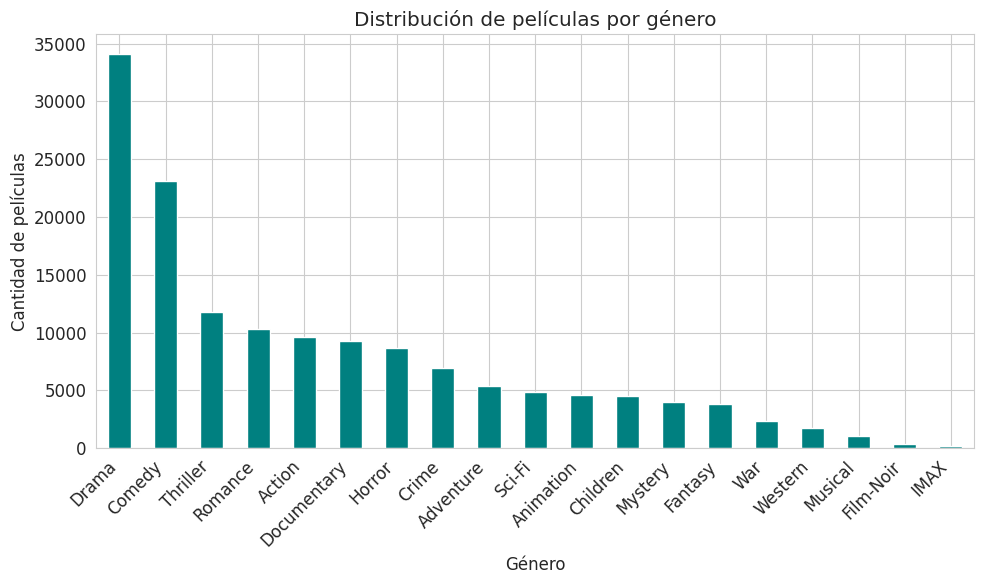

In [8]:
plt.figure(figsize=(10, 6))
genre_counts.drop("(no genres listed)", errors="ignore").plot(kind="bar", color="teal")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de películas por género")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 3.2 `ratings`

In [9]:
ratings.head(10)

,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0
5,1,34,2.0
6,1,36,1.0
7,1,80,5.0
8,1,110,3.0
9,1,111,5.0


In [10]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 31963989 entries, 0 to 31963988
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int32  
 1   movieId  int32  
 2   rating   float32
dtypes: float32(1), int32(2)
memory usage: 365.8 MB


In [11]:
print("Dimensiones:", ratings.shape)
print("\nValores nulos por columna:")
print(ratings.isnull().sum())
print("\nDuplicados (userId, movieId):", ratings.duplicated(subset=["userId", "movieId"]).sum())
print("Rango de rating:", ratings["rating"].min(), "-", ratings["rating"].max())
print("Valores posibles de rating:", sorted(ratings["rating"].unique()))
print("Usuarios únicos:", ratings["userId"].nunique())
print("Películas calificadas:", ratings["movieId"].nunique(), "de", movies.shape[0], "en el catálogo")


Dimensiones: (31963989, 3)

Valores nulos por columna:


userId     0
movieId    0
rating     0
dtype: int64



Duplicados (userId, movieId): 0
Rango de rating: 0.5 - 5.0


Valores posibles de rating: [np.float32(0.5), np.float32(1.0), np.float32(1.5), np.float32(2.0), np.float32(2.5), np.float32(3.0), np.float32(3.5), np.float32(4.0), np.float32(4.5), np.float32(5.0)]
Usuarios únicos: 200948


Películas calificadas: 83852 de 86967 en el catálogo


In [12]:
# rating_datetime se revisa por separado, leyendo el CSV por partes (chunksize) para no
# cargar la columna completa de fechas en memoria solo para conocer el rango cubierto.
date_min, date_max = None, None
for chunk in pd.read_csv(DATA_DIR / "ratings.csv", usecols=["rating_datetime"], chunksize=2_000_000):
    dt = pd.to_datetime(chunk["rating_datetime"])
    c_min, c_max = dt.min(), dt.max()
    date_min = c_min if date_min is None or c_min < date_min else date_min
    date_max = c_max if date_max is None or c_max > date_max else date_max

print("Rango de fechas de las calificaciones:", date_min, "-", date_max)


Rango de fechas de las calificaciones: 1995-01-09 11:46:44 - 2023-10-13 02:29:07


**Unidad de observación de `ratings`:** cada fila representa **una calificación** que un usuario
(`userId`) dio a una película (`movieId`) en un momento (`rating_datetime`).

- Sin nulos, sin pares `(userId, movieId)` duplicados: cada usuario calificó cada película como
  máximo una vez.
- `rating` toma 10 valores posibles (0.5 a 5.0 en pasos de 0.5), consistente con la escala de
  media estrella de MovieLens — no es una variable continua libre, sino discreta ordinal.
- De las 86 967 películas del catálogo, solo **83 852 (96.4 %)** tienen al menos una
  calificación; el resto no aparece en `ratings`.
- El periodo cubierto va de **1995-01 a 2023-10**, casi 29 años de actividad.

In [13]:
desc = ratings["rating"].describe()
print(desc)
print("\nModa:", ratings["rating"].mode()[0])
print("Asimetría (skew):", ratings["rating"].skew())


count    3.196399e+07
mean     3.540369e+00
std      1.058978e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Moda: 4.0


Asimetría (skew): -0.7188878


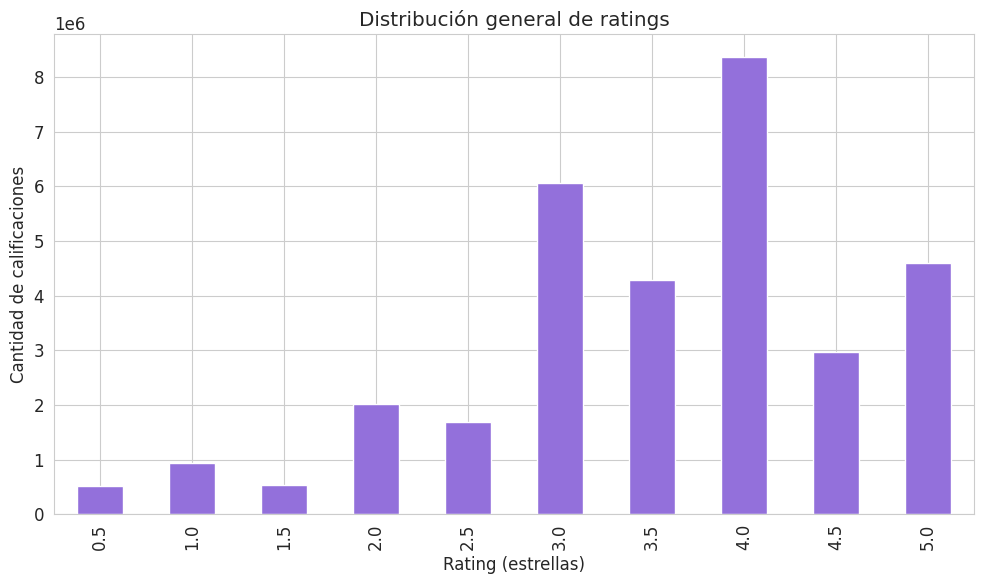

In [14]:
plt.figure(figsize=(10, 6))
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="mediumpurple")
plt.xlabel("Rating (estrellas)")
plt.ylabel("Cantidad de calificaciones")
plt.title("Distribución general de ratings")
plt.tight_layout()
plt.show()


**Interpretación:** el promedio general es **3.54** (mediana 3.5, desviación estándar 1.06). La
distribución tiene asimetría negativa (cola hacia la izquierda): los usuarios califican con más
frecuencia entre 3 y 4 estrellas, y las calificaciones muy bajas (0.5–1.5) son minoritarias. Los
valores enteros (3.0, 4.0, 5.0) son notablemente más usados que los intermedios (.5), lo que sugiere
un sesgo de los usuarios hacia calificaciones "redondas".

#### Actividad por usuario y por película

In [15]:
ratings_per_movie = ratings.groupby("movieId").size()
ratings_per_user = ratings.groupby("userId").size()

print("=== Calificaciones por película ===")
print(ratings_per_movie.describe())
print("\n=== Calificaciones por usuario ===")
print(ratings_per_user.describe())


=== Calificaciones por película ===
count     83852.000000
mean        381.195308
std        2601.042893
min           1.000000
25%           2.000000
50%           5.000000
75%          25.000000
max      102929.000000
dtype: float64

=== Calificaciones por usuario ===
count    200948.000000
mean        159.065972
std         281.494519
min          18.000000
25%          36.000000
50%          73.000000
75%         166.250000
max       33229.000000
dtype: float64


**Hallazgo clave:** la actividad está muy concentrada (típico de datasets de interacción tipo
"long tail"):

- **Por película:** la mediana es de solo 5 calificaciones, pero el máximo es 102 929. El 75 % de
  las películas tiene 25 calificaciones o menos, mientras un puñado de títulos muy populares
  concentra la mayoría del volumen.
- **Por usuario:** cada usuario calificó en promedio 159 películas (mediana 73), con un mínimo de
  18 (el dataset probablemente filtra usuarios con muy poca actividad) y un máximo de 33 229.

Esto implica que cualquier ranking por promedio de rating **debe filtrar por un mínimo de
calificaciones**, o películas con 1-2 votos de 5 estrellas dominarán el top sin ser representativas.

## 4. Integración `movies` + `ratings`

**Clave de unión:** `movieId`, presente en ambas tablas.

Ya se verificó en la sección anterior que todos los `movieId` de `ratings` existen en `movies`
(no hay calificaciones "huérfanas"). Por lo tanto un `merge` tipo `inner` sobre `movieId` es seguro:
no perderá calificaciones ni introducirá filas basura, y solo excluirá del resultado a las 3 115
películas del catálogo que nunca fueron calificadas (que de todas formas no aportan a un análisis
basado en ratings).

In [16]:
movie_stats = (
    ratings.groupby("movieId")["rating"]
    .agg(num_ratings="count", avg_rating="mean", std_rating="std")
    .reset_index()
)
movie_stats = movie_stats.merge(
    movies[["movieId", "title", "genres", "release_year"]], on="movieId", how="left"
)
movie_stats["avg_rating"] = movie_stats["avg_rating"].round(3)
movie_stats["std_rating"] = movie_stats["std_rating"].round(3)

print("Filas resultantes:", movie_stats.shape[0], "(esperado: películas con al menos 1 rating)")
assert movie_stats.shape[0] == ratings["movieId"].nunique(), "El merge no coincide con lo esperado"
assert movie_stats["movieId"].duplicated().sum() == 0, "El merge generó duplicados inesperados"
print("Validación OK: sin duplicados y sin pérdida inesperada de registros.")
movie_stats.head(10)


Filas resultantes: 83852 (esperado: películas con al menos 1 rating)
Validación OK: sin duplicados y sin pérdida inesperada de registros.


,movieId,num_ratings,avg_rating,std_rating,title,genres,release_year
0,1,68997,3.897,0.921,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,28904,3.276,0.956,Jumanji,Adventure|Children|Fantasy,1995
2,3,13134,3.139,1.012,Grumpier Old Men,Comedy|Romance,1995
3,4,2806,2.845,1.106,Waiting to Exhale,Comedy|Drama|Romance,1995
4,5,13154,3.060,0.999,Father of the Bride Part II,Comedy,1995
5,6,29490,3.868,0.875,Heat,Action|Crime|Thriller,1995
6,7,13585,3.364,0.964,Sabrina,Comedy|Romance,1995
7,8,1510,3.116,0.989,Tom and Huck,Adventure|Children,1995
8,9,4154,2.988,0.964,Sudden Death,Action,1995
9,10,32474,3.428,0.876,GoldenEye,Action|Adventure|Thriller,1995


## 5. Análisis conjunto `movies` + `ratings`

### 5.1 Películas más y menos calificadas (volumen)

In [17]:
top_n = 10
top_viewed = movie_stats.nlargest(top_n, "num_ratings")
print(f"Top {top_n} películas más calificadas:")
top_viewed[["title", "num_ratings", "avg_rating", "std_rating"]]


Top 10 películas más calificadas:


,title,num_ratings,avg_rating,std_rating
314,"Shawshank Redemption, The",102929,4.405,0.766
351,Forrest Gump,100296,4.053,0.935
292,Pulp Fiction,98409,4.197,0.946
2480,"Matrix, The",93808,4.156,0.907
585,"Silence of the Lambs, The",90330,4.148,0.863
257,Star Wars: Episode IV - A New Hope,85010,4.100,0.993
2867,Fight Club,77332,4.229,0.860
475,Jurassic Park,75233,3.699,0.937
522,Schindler's List,73849,4.237,0.883
4888,"Lord of the Rings: The Fellowship of the Ring, The",73122,4.092,1.009


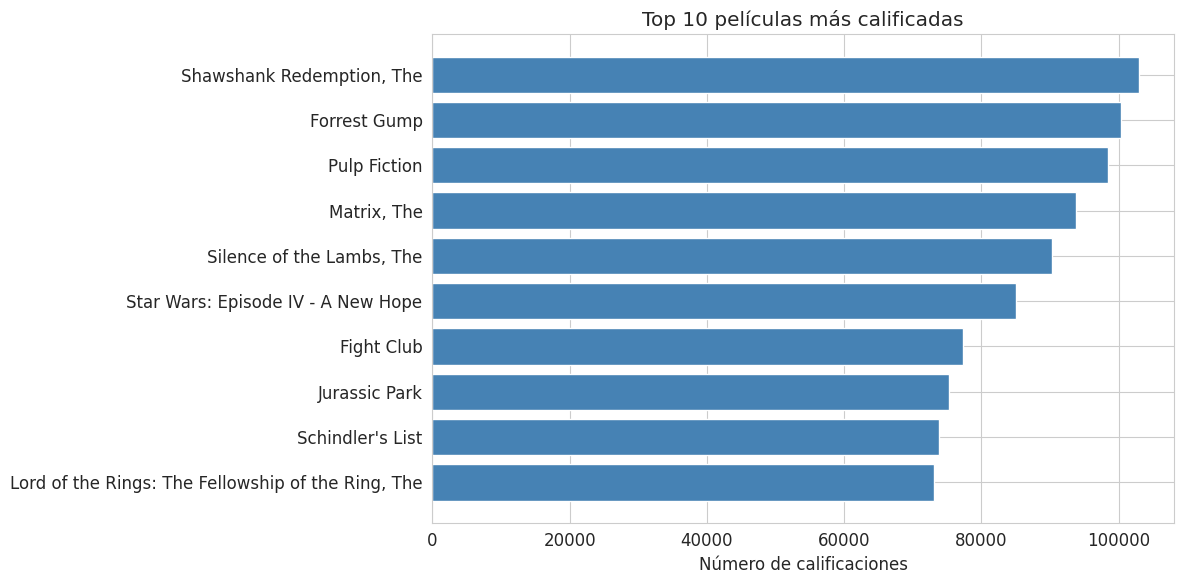

In [18]:
plt.figure(figsize=(12, 6))
plt.barh(top_viewed["title"], top_viewed["num_ratings"], color="steelblue")
plt.xlabel("Número de calificaciones")
plt.title(f"Top {top_n} películas más calificadas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [19]:
bottom_n = 10
bottom_viewed = movie_stats[movie_stats["num_ratings"] >= 1].nsmallest(bottom_n, "num_ratings")
print(f"Bottom {bottom_n} películas menos calificadas:")
bottom_viewed[["title", "num_ratings", "avg_rating", "std_rating"]]


Bottom 10 películas menos calificadas:


,title,num_ratings,avg_rating,std_rating
3263,Condo Painting,1,3.0,NaN
3463,Stacy's Knights,1,1.0,NaN
5794,Soap Girl,1,3.5,NaN
8373,Break of Hearts,1,3.0,NaN
8464,B.F.'s Daughter,1,4.0,NaN
8986,Crossing the Bridge,1,3.0,NaN
9008,Deadly Advice,1,2.5,NaN
9034,Staggered,1,2.5,NaN
9619,White Banners,1,3.0,NaN
9644,Always a Bridesmaid,1,5.0,NaN


**Justificación:** el volumen de calificaciones aproxima la popularidad/exposición de una
película, no su calidad. Se usa como métrica independiente de `avg_rating` precisamente para poder
después comparar "qué tan vista" vs. "qué tan bien calificada" está una película, y detectar que
son cosas distintas.

### 5.2 Películas mejor y peor calificadas

In [20]:
min_ratings = 50  # umbral para evitar que 1-2 votos decidan el ranking
qualified = movie_stats[movie_stats["num_ratings"] >= min_ratings]
print(f"Películas con al menos {min_ratings} calificaciones: {len(qualified)} de {len(movie_stats)}")

top_rated = qualified.nlargest(10, "avg_rating")
bottom_rated = qualified.nsmallest(10, "avg_rating")

print("\nMejor calificadas:")
display(top_rated[["title", "num_ratings", "avg_rating", "std_rating"]])
print("\nPeor calificadas:")
display(bottom_rated[["title", "num_ratings", "avg_rating", "std_rating"]])


Películas con al menos 50 calificaciones: 15986 de 83852

Mejor calificadas:


,title,num_ratings,avg_rating,std_rating
44007,Planet Earth II,1956,4.447,0.816
39180,Planet Earth,2948,4.444,0.764
43861,Band of Brothers,2811,4.427,0.769
314,"Shawshank Redemption, The",102929,4.405,0.766
840,"Godfather, The",66440,4.317,0.875
58323,Parasite,11670,4.312,0.775
47740,Blue Planet II,1163,4.300,0.923
56399,Twin Peaks,1140,4.299,0.875
65479,Twelve Angry Men,449,4.286,0.766
49,"Usual Suspects, The",67750,4.265,0.793



Peor calificadas:


,title,num_ratings,avg_rating,std_rating
8146,SuperBabies: Baby Geniuses 2,257,0.866,0.852
6361,From Justin to Kelly,472,1.006,0.856
4670,Glitter,757,1.129,0.849
33429,Barbie & Her Sisters in the Great Puppy Adventure,72,1.181,1.293
1740,Barney's Great Adventure,440,1.198,0.918
6465,Gigli,838,1.204,0.954
9607,Son of the Mask,832,1.221,0.936
24055,Justin Bieber: Never Say Never,63,1.238,1.208
12618,Disaster Movie,715,1.248,1.066
5628,Faces of Death 6,172,1.285,1.214


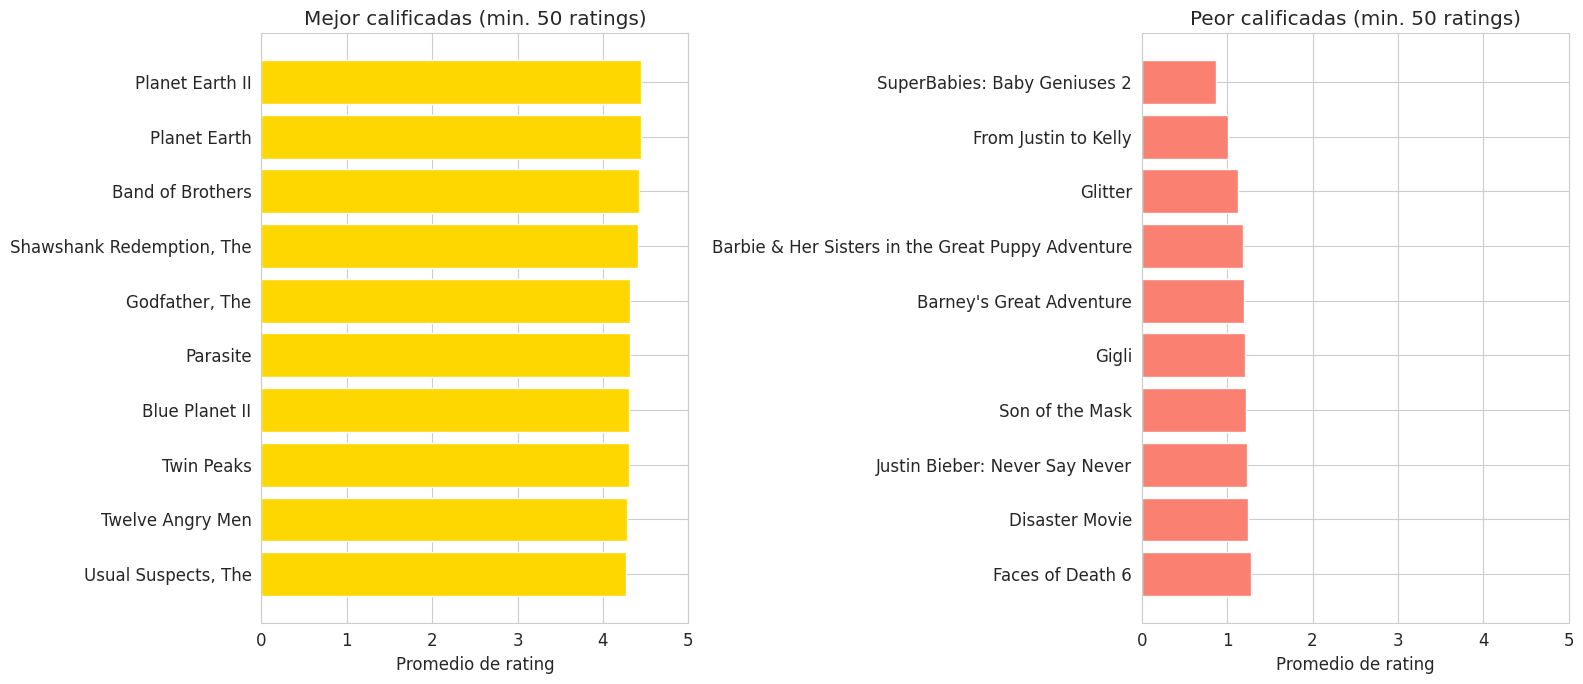

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top_rated["title"], top_rated["avg_rating"], color="gold")
axes[0].set_xlim(0, 5)
axes[0].set_xlabel("Promedio de rating")
axes[0].set_title(f"Mejor calificadas (min. {min_ratings} ratings)")
axes[0].invert_yaxis()

axes[1].barh(bottom_rated["title"], bottom_rated["avg_rating"], color="salmon")
axes[1].set_xlim(0, 5)
axes[1].set_xlabel("Promedio de rating")
axes[1].set_title(f"Peor calificadas (min. {min_ratings} ratings)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Sobre el sesgo del promedio simple:** ordenar solo por `avg_rating`, incluso filtrando por un
mínimo de calificaciones, sigue favoreciendo películas con pocas calificaciones "afortunadas" frente
a películas masivamente vistas y consistentemente bien valoradas. Para corregirlo se calcula un
**promedio bayesiano** (misma idea del "weighted rating" de IMDB), que acerca el promedio de una
película hacia la media global cuando tiene pocas calificaciones, y lo deja casi intacto cuando tiene
muchas:

$$\text{bayesian} = \frac{n \cdot \bar{r} + m \cdot C}{n + m}$$

donde $n$ = número de calificaciones de la película, $\bar{r}$ = su promedio, $C$ = promedio
global ponderado, $m$ = umbral de "confianza mínima" (se usa m=50, igual al filtro anterior).

In [22]:
C = (movie_stats["num_ratings"] * movie_stats["avg_rating"]).sum() / movie_stats["num_ratings"].sum()
m = 50
movie_stats["bayesian_rating"] = (
    movie_stats["num_ratings"] * movie_stats["avg_rating"] + m * C
) / (movie_stats["num_ratings"] + m)

print(f"Promedio global ponderado (C): {C:.3f}")
top_bayes = movie_stats.sort_values("bayesian_rating", ascending=False).head(10)
top_bayes[["title", "num_ratings", "avg_rating", "bayesian_rating", "release_year"]]


Promedio global ponderado (C): 3.540


,title,num_ratings,avg_rating,bayesian_rating,release_year
39180,Planet Earth,2948,4.444,4.428929,2006
44007,Planet Earth II,1956,4.447,4.424402,2016
43861,Band of Brothers,2811,4.427,4.411505,2001
314,"Shawshank Redemption, The",102929,4.405,4.404580,1994
840,"Godfather, The",66440,4.317,4.316416,1972
58323,Parasite,11670,4.312,4.308708,2019
47740,Blue Planet II,1163,4.300,4.268688,2017
56399,Twin Peaks,1140,4.299,4.267124,1989
49,"Usual Suspects, The",67750,4.265,4.264465,1995
1173,12 Angry Men,21863,4.265,4.263346,1957


**Hallazgo:** con el ajuste bayesiano, el top se estabiliza alrededor de clásicos con muchísimas
calificaciones y promedios altos de forma consistente — *Shawshank Redemption* (102 929
calificaciones, 4.40), *El Padrino* (66 440, 4.32), *Sospechosos Habituales* (67 750, 4.26),
*12 Hombres en Pugna* (21 863, 4.26) — junto con series/documentales muy bien valorados
(*Planet Earth*, *Band of Brothers*). Esto contrasta con el top del promedio simple, típicamente
dominado por títulos con muy pocos votos.

### 5.3 Relación entre volumen de calificaciones y calidad percibida

In [23]:
corr_lineal = movie_stats["num_ratings"].corr(movie_stats["avg_rating"])
corr_log = np.log1p(movie_stats["num_ratings"]).corr(movie_stats["avg_rating"])
print(f"Correlación de Pearson (num_ratings, avg_rating): {corr_lineal:.3f}")
print(f"Correlación de Pearson (log(1+num_ratings), avg_rating): {corr_log:.3f}")


Correlación de Pearson (num_ratings, avg_rating): 0.098
Correlación de Pearson (log(1+num_ratings), avg_rating): 0.185


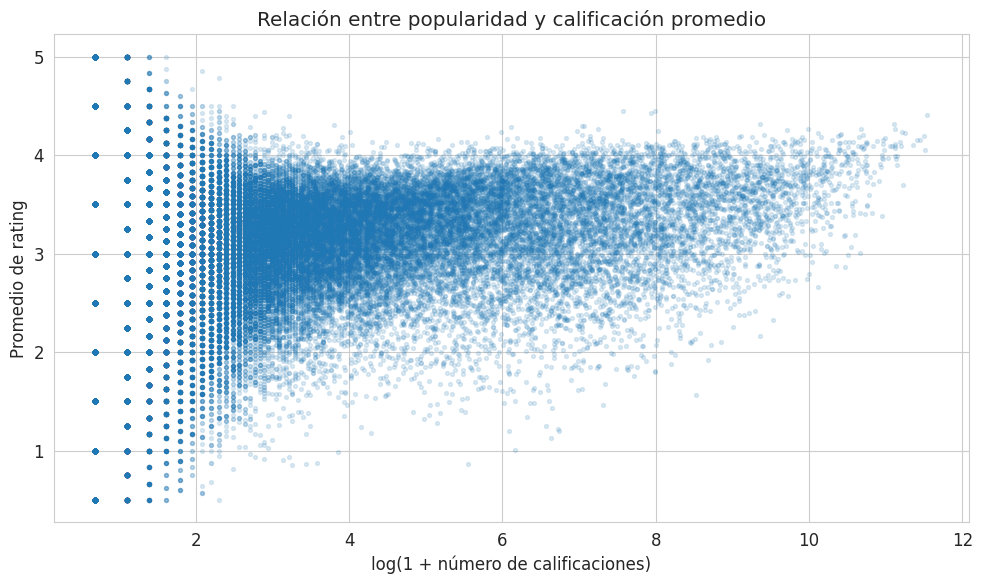

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(movie_stats["num_ratings"]), movie_stats["avg_rating"], alpha=0.15, s=8)
plt.xlabel("log(1 + número de calificaciones)")
plt.ylabel("Promedio de rating")
plt.title("Relación entre popularidad y calificación promedio")
plt.tight_layout()
plt.show()


**Pregunta que responde:** ¿las películas más vistas son también las mejor calificadas?

**Resultado:** la correlación lineal directa es muy débil (≈0.10) y sigue siendo débil incluso en
escala logarítmica (≈0.19). Es decir, **popularidad y calidad percibida están casi
desacopladas** en este dataset: hay películas poco vistas con promedios altísimos (con muestras
pequeñas, poco confiables) y películas extremadamente vistas con promedios moderados. Una
correlación positiva pero débil es consistente con la idea de que las películas muy vistas tienden
a tener *menos varianza* en su promedio (la ley de los grandes números las acerca a la media
general) más que a ser sistemáticamente mejores.

**Limitación:** esto es correlación, no causalidad, y la relación no es necesariamente lineal (el
dispersograma en escala log sugiere más bien un "embudo": la dispersión de `avg_rating` se reduce a
medida que crece el número de calificaciones, mientras el promedio se mantiene cerca de 3.5).

### 5.4 Calificación promedio por género

In [25]:
mg = movie_stats[["movieId", "genres", "num_ratings", "avg_rating"]].copy()
mg["genres"] = mg["genres"].str.split("|")
mg = mg.explode("genres")

genre_stats = (
    mg.groupby("genres")
    .apply(lambda g: pd.Series({
        "n_movies": g["movieId"].nunique(),
        "total_ratings": g["num_ratings"].sum(),
        "avg_rating_weighted": (g["num_ratings"] * g["avg_rating"]).sum() / g["num_ratings"].sum(),
    }))
    .sort_values("avg_rating_weighted", ascending=False)
)
genre_stats


,n_movies,total_ratings,avg_rating_weighted
genres,,,
Film-Noir,350.0,304710.0,3.915857
War,2225.0,1594105.0,3.791725
Crime,6689.0,5372233.0,3.691907
Documentary,9041.0,427171.0,3.691369
Drama,33075.0,13954244.0,3.682552
Mystery,3886.0,2613442.0,3.673474
Animation,4581.0,2214357.0,3.615297
Western,1489.0,596651.0,3.600187
IMAX,195.0,1494176.0,3.593273


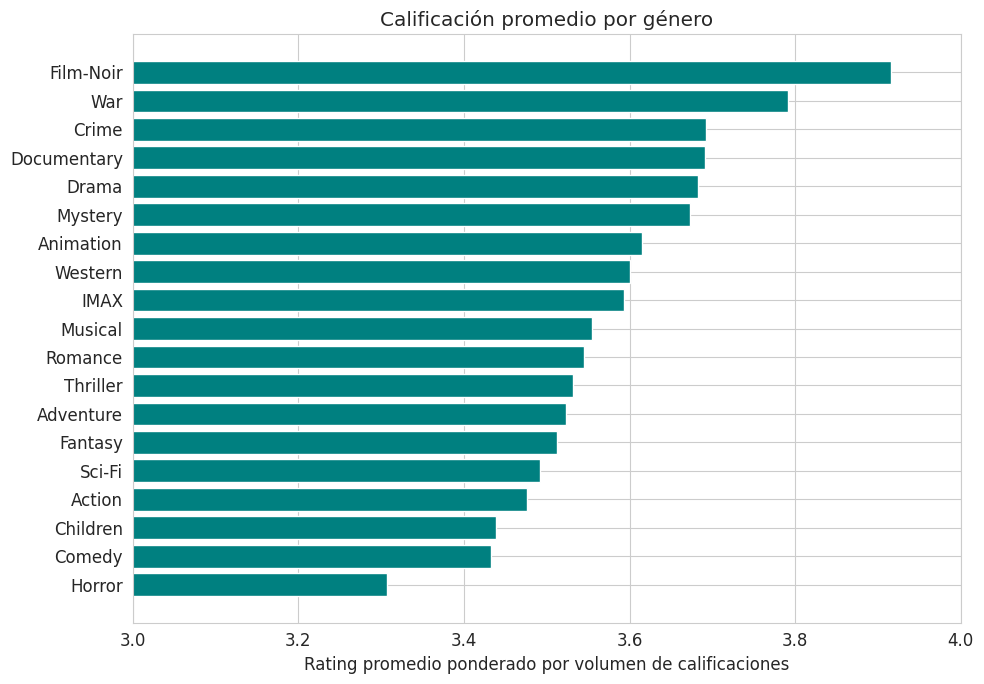

In [26]:
plt.figure(figsize=(10, 7))
order = genre_stats.drop("(no genres listed)", errors="ignore").index
plt.barh(order, genre_stats.loc[order, "avg_rating_weighted"], color="teal")
plt.xlabel("Rating promedio ponderado por volumen de calificaciones")
plt.title("Calificación promedio por género")
plt.xlim(3, 4)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Por qué se pondera por volumen:** un promedio simple entre películas trataría igual a un
documental con 20 calificaciones que a una con 200 000, distorsionando el resultado hacia géneros
con muchos títulos de nicho. Ponderar por `num_ratings` da el promedio real que experimentaron los
usuarios de ese género.

**Hallazgo:** `Film-Noir` (3.92), `War` (3.79) y `Crime` (3.69) tienen los promedios ponderados más
altos; `Horror` (3.31) y `Comedy` (3.43) los más bajos entre los géneros con volumen relevante. Los
géneros mejor valorados tienden a coincidir con géneros "de prestigio" (dramas serios, crimen,
guerra) frente a géneros de consumo masivo/ligero (comedia, terror), aunque la diferencia entre el
género mejor y peor valorado es de apenas ~0.6 puntos sobre una escala de 5 — la variación entre
géneros es real pero moderada.

### 5.5 Evolución temporal: año de estreno y calificaciones

In [27]:
by_year = movie_stats.dropna(subset=["release_year"])
by_year_g = (
    by_year.groupby("release_year")
    .apply(lambda g: pd.Series({
        "avg_rating_weighted": (g["num_ratings"] * g["avg_rating"]).sum() / g["num_ratings"].sum(),
        "n_movies": len(g),
        "total_ratings": g["num_ratings"].sum(),
    }))
)
by_year_g.tail(10)


,avg_rating_weighted,n_movies,total_ratings
release_year,,,
2014,3.633899,2827.0,568795.0
2015,3.564945,3029.0,469937.0
2016,3.540925,3129.0,404137.0
2017,3.544946,3226.0,357065.0
2018,3.479386,3151.0,256957.0
2019,3.554170,3053.0,241105.0
2020,3.330706,2600.0,99429.0
2021,3.323736,2302.0,83672.0
2022,3.362975,2084.0,70019.0


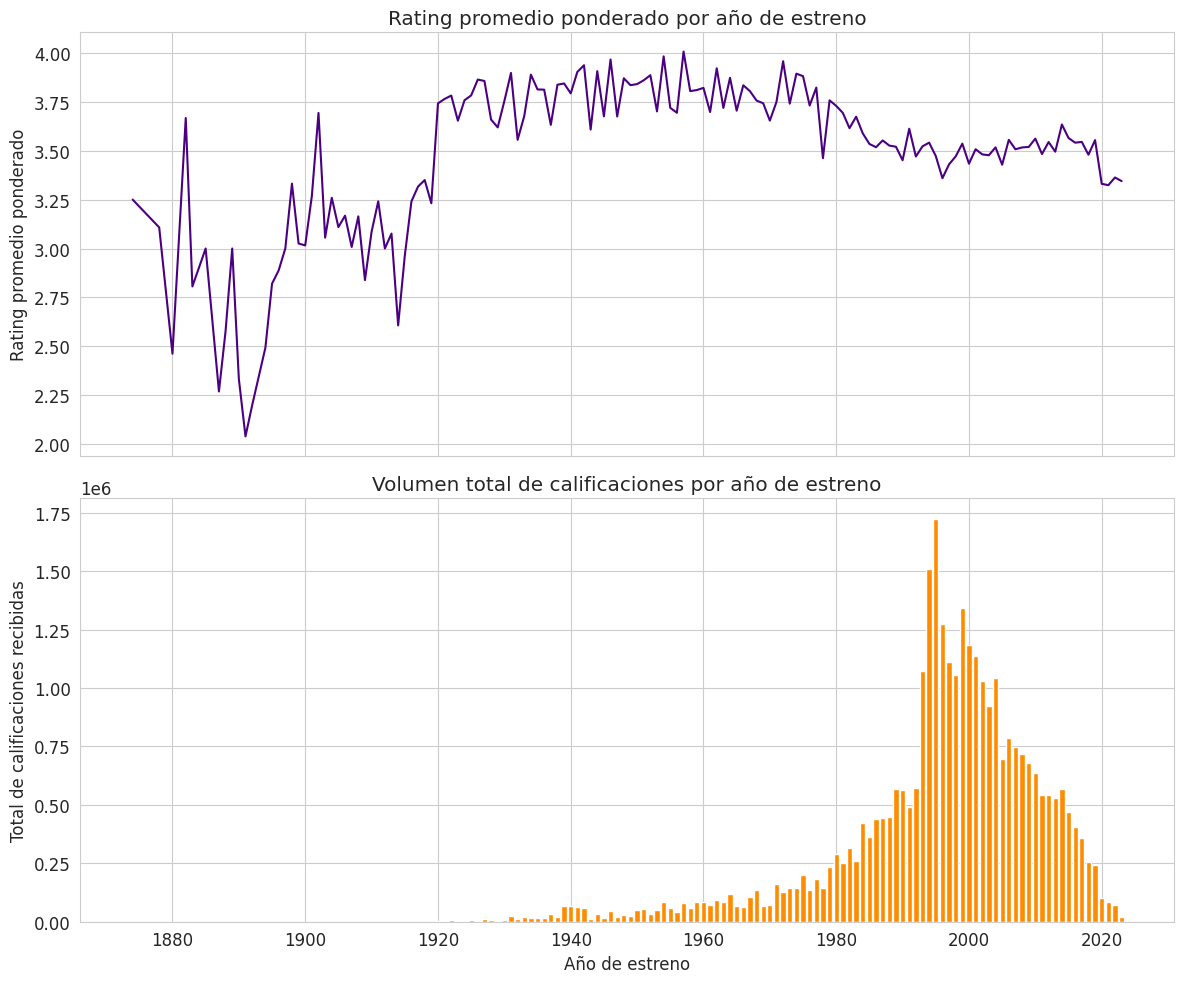

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axes[0].plot(by_year_g.index, by_year_g["avg_rating_weighted"], color="indigo")
axes[0].set_ylabel("Rating promedio ponderado")
axes[0].set_title("Rating promedio ponderado por año de estreno")

axes[1].bar(by_year_g.index, by_year_g["total_ratings"], color="darkorange")
axes[1].set_ylabel("Total de calificaciones recibidas")
axes[1].set_xlabel("Año de estreno")
axes[1].set_title("Volumen total de calificaciones por año de estreno")

plt.tight_layout()
plt.show()


**Interpretación:** el volumen de calificaciones por año de estreno crece hasta mediados de los
2010 y luego cae fuertemente en películas de 2020-2023 — esperable, porque esas películas han tenido
menos tiempo para acumular calificaciones (no es un juicio de calidad, es una limitación temporal
del corte de datos, recolectados hasta octubre de 2023). El rating promedio ponderado se mantiene
relativamente estable entre 3.3 y 3.6 a lo largo de casi 30 años, con una leve caída en 2020-2023
que probablemente combina el efecto de "pocas calificaciones todavía" con calidad percibida real de
estrenos recientes.

**Limitación:** no se debe interpretar la caída reciente como "las películas nuevas son peores": la
cantidad de observaciones por año no es una población estable, y los años recientes están
subrepresentados por definición del corte temporal del dataset.

## 6. Funciones de búsqueda

In [29]:
def buscar_por_nombre(nombre: str) -> pd.DataFrame:
    """Busca películas cuyo título contenga `nombre` (case-insensitive)."""
    resultados = movie_stats[movie_stats["title"].str.contains(nombre, case=False, na=False)]
    return resultados[
        ["title", "genres", "release_year", "num_ratings", "avg_rating", "bayesian_rating"]
    ].sort_values("num_ratings", ascending=False)


def buscar_por_id(movie_id: int) -> pd.DataFrame:
    """Busca una película por su movieId."""
    resultado = movie_stats[movie_stats["movieId"] == movie_id]
    if len(resultado) == 0:
        print(f"No se encontró película con movieId={movie_id}")
        return pd.DataFrame()
    return resultado[
        ["title", "genres", "release_year", "num_ratings", "avg_rating", "bayesian_rating"]
    ]


buscar_por_nombre("Toy Story")


,title,genres,release_year,num_ratings,avg_rating,bayesian_rating
0,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,68997,3.897,3.896742
3021,Toy Story 2,Adventure|Animation|Children|Comedy|Fantasy,1999,32683,3.812,3.811585
14810,Toy Story 3,Adventure|Animation|Children|Comedy|Fantasy|IMAX,2010,20327,3.828,3.827294
57947,Toy Story 4,Adventure|Animation|Children|Comedy,2019,2802,3.589,3.588147
20455,Toy Story of Terror,Animation|Children|Comedy,2013,359,3.343,3.367128
23868,Toy Story That Time Forgot,Animation|Children,2014,337,3.217,3.258779
22508,Toy Story Toons: Hawaiian Vacation,Adventure|Animation|Children|Comedy|Fantasy,2011,139,3.043,3.174578
22509,Toy Story Toons: Small Fry,Adventure|Animation|Children|Comedy|Fantasy,2011,123,3.077,3.210921
23866,Toy Story Toons: Partysaurus Rex,Animation|Children|Comedy,2012,91,3.324,3.400725


In [30]:
buscar_por_id(1)

,title,genres,release_year,num_ratings,avg_rating,bayesian_rating
0,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,68997,3.897,3.896742


## 7. Conclusiones

- El catálogo (`movies`, 86 967 títulos) está limpio: sin nulos ni duplicados, y `movieId` es una
  clave primaria confiable. Sin embargo, el 7.7 % de las películas no tiene género asignado, lo cual
  limita ligeramente los análisis por género.
- Solo el 96.4 % del catálogo (83 852 películas) tiene al menos una calificación en `ratings`; el
  resto no aporta a este análisis.
- La actividad de calificación sigue una distribución de "cola larga" muy marcada: la mediana de
  calificaciones por película es 5, pero el título más calificado tiene 102 929. Esto obliga a usar
  umbrales mínimos (o ajustes bayesianos) en cualquier ranking por promedio.
- **Popularidad (volumen de calificaciones) y calidad percibida (promedio) están débilmente
  correlacionadas** (Pearson ≈ 0.10, y ≈0.19 en escala logarítmica): ver mucho una película no
  implica que esté bien calificada, y viceversa.
- Existen diferencias moderadas de calificación promedio entre géneros (Film-Noir y War arriba,
  Horror y Comedy abajo), con una brecha de ~0.6 puntos entre el género mejor y peor valorado.
- El rating promedio ponderado se mantiene notablemente estable (3.3–3.6) a lo largo de casi 30 años
  de estrenos, sin evidencia de una tendencia sostenida de mejora o deterioro en la calificación
  percibida de las películas por año de estreno.
- **Limitaciones:** los años más recientes (2020-2023) tienen mucho menos volumen de datos por
  razones temporales, no de calidad; los análisis de correlación aquí presentados son descriptivos y
  no implican causalidad; y el promedio simple sin ajustar puede ser engañoso para películas con
  pocas calificaciones, por lo que se prefirió el promedio bayesiano para los rankings de "mejor
  calificadas".